In [56]:
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

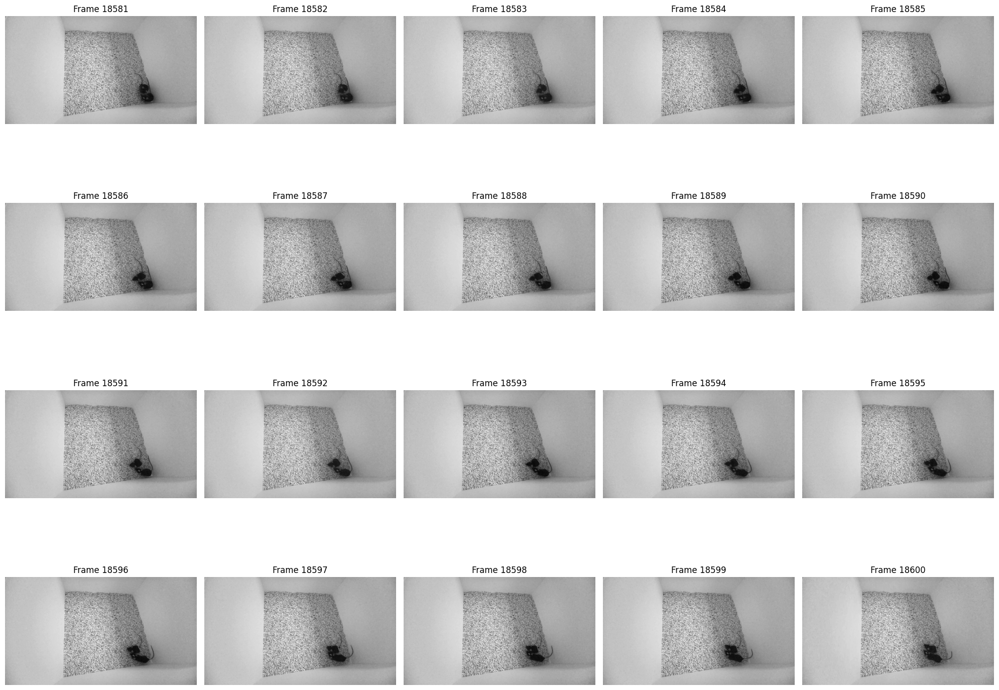

In [57]:
start_frame = 18581
end_frame = start_frame + 20


# frame1_path = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/030457.jpg"
# frame2_path = "/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/030458.jpg"
# frame1 = cv2.imread(frame1_path)
# frame2 = cv2.imread(frame2_path)

frame_paths = [
    f"/home/adam/.sam3_zero_projects/553344c8-social-full-video/videos/05cfafae/frames/{i:06d}.jpg"
    for i in range(start_frame, end_frame)
]
frames = [cv2.imread(path) for path in frame_paths]
gray_frames = [cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) for frame in frames]


# show image in grayscale in subplots
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(gray_frames[i], cmap="gray")
    ax.set_title(f"Frame {start_frame + i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [58]:
import cv2
import numpy as np

def preprocess(frame, blur_ksize=15):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
    gray = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)
    return gray


def compute_temporal_avg_flow(frames, K=5):
    """
    Compute temporally averaged optical flow over sliding window.

    Returns:
        avg_flows: list of (H, W, 2) arrays
    """
    assert len(frames) >= K + 1

    processed = [preprocess(f) for f in frames]
    flows = []

    # compute pairwise flows
    for i in range(len(processed) - 1):
        flow = cv2.calcOpticalFlowFarneback(
            processed[i], processed[i+1], None,
            pyr_scale=0.5,
            levels=3,
            winsize=21,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )
        flows.append(flow)

    # temporal averaging
    avg_flows = []
    for i in range(len(flows) - K + 1):
        window = flows[i:i+K]
        mean_flow = np.mean(window, axis=0)
        avg_flows.append(mean_flow)

    return avg_flows

In [59]:
def flow_to_masked_vectors(flow, mag_quantile_thresh=0.99):
    """
    Extract masked flow vectors based on magnitude threshold.
    """
    fx = flow[..., 0]
    fy = flow[..., 1]

    mag = np.sqrt(fx**2 + fy**2)

    print('quantile: ', float(np.quantile(mag, mag_quantile_thresh)))

    mask = mag > np.quantile(mag, mag_quantile_thresh)

    return fx, fy, mag, mask

In [ ]:
import matplotlib.pyplot as plt

def visualize_flow(frame, flow, mag_quantile_thresh=0.99, stride=10, scale=None):
    """
    Overlay masked flow vectors on frame.
    """
    fx, fy, mag, mask = flow_to_masked_vectors(flow, mag_quantile_thresh)
    h, w = mag.shape
    y, x = np.mgrid[0:h, 0:w]

    # subsample
    x = x[::stride, ::stride]
    y = y[::stride, ::stride]
    fx = fx[::stride, ::stride]
    fy = fy[::stride, ::stride]
    mask = mask[::stride, ::stride]

    # apply mask
    x = x[mask]
    y = y[mask]
    fx = fx[mask] + 10
    fy = fy[mask] + 10

    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    plt.quiver(
        x, y, fx, fy,
        angles='xy',
        scale_units='xy',
        scale=scale if scale else 1,
        color='red',
        width=0.002
    )

    plt.axis("off")
    plt.title("Coherent Motion (Thresholded)")
    plt.show()

In [66]:
def visualize_heatmap(frame, mag):
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.imshow(mag, cmap="hot", alpha=0.5)
    plt.axis("off")
    plt.title("Motion Magnitude (Temporal Avg)")
    plt.show()

In [67]:
def run_pipeline(frames, K=5, mag_quantile_thresh=0.99, stride=10):
    avg_flows = compute_temporal_avg_flow(frames, K=K)

    for i, flow in enumerate(avg_flows):
        frame = frames[i + K // 2]  # center frame of window

        fx, fy, mag, mask = flow_to_masked_vectors(flow, mag_quantile_thresh)

        visualize_heatmap(frame, mag)
        visualize_flow(frame, flow, mag_quantile_thresh, stride)

In [68]:
def render_flow_video(
    frames,
    avg_flows,
    out_path="flow.mp4",
    mag_quantile_thresh=0.99,
    stride=10,
    scale=5.0,
    normalize=False,
):
    """
    Render temporally averaged flow as arrows on video.

    Parameters
    ----------
    scale : float
        Multiplier for vector length (critical!)
    normalize : bool
        If True, all arrows have same length (direction only)
    """
    h, w = frames[0].shape[:2]

    out = cv2.VideoWriter(
        out_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        20,
        (w, h)
    )

    for i, flow in enumerate(avg_flows):
        frame = frames[i].copy()

        fx = flow[..., 0]
        fy = flow[..., 1]
        mag = np.sqrt(fx**2 + fy**2)

        for y in range(0, h, stride):
            for x in range(0, w, stride):
                if mag[y, x] > np.quantile(mag, mag_quantile_thresh):
                    dx = fx[y, x]
                    dy = fy[y, x]

                    if normalize:
                        norm = np.sqrt(dx**2 + dy**2) + 1e-6
                        dx /= norm
                        dy /= norm

                    # SCALE HERE (critical)
                    x2 = int(x + dx * scale)
                    y2 = int(y + dy * scale) 

                    cv2.arrowedLine(
                        frame,
                        (x, y),
                        (x2, y2),
                        (0, 0, 255),
                        1,
                        tipLength=0.3
                    )

        out.write(frame)

    out.release()

quantile:  2.018476497056554e-09


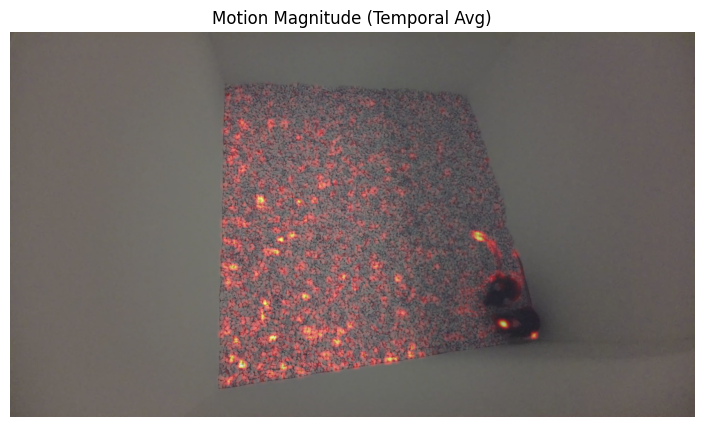

quantile:  2.018476497056554e-09


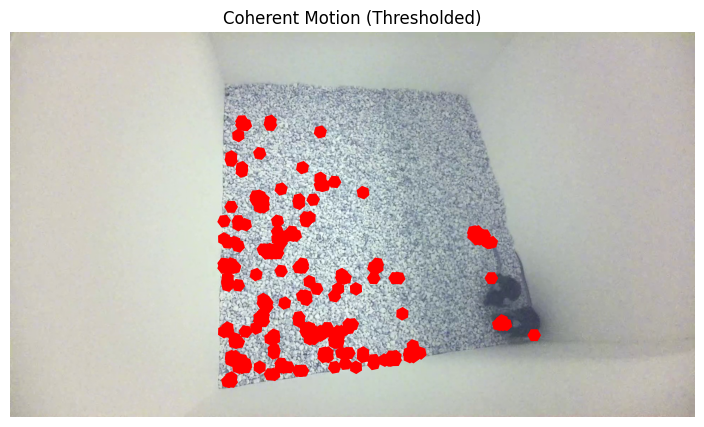

quantile:  2.0194406147311383e-09


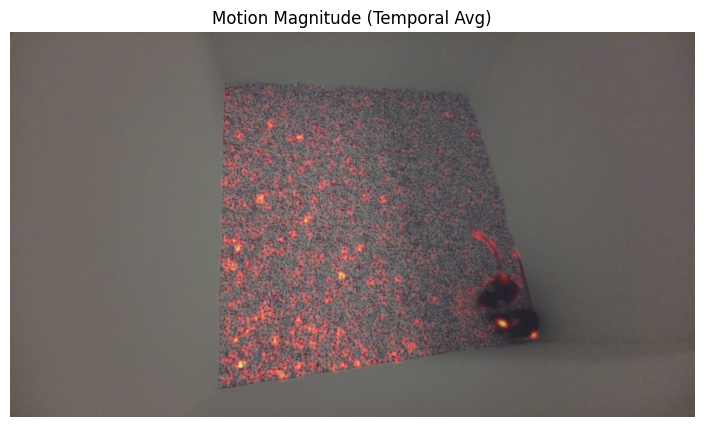

quantile:  2.0194406147311383e-09


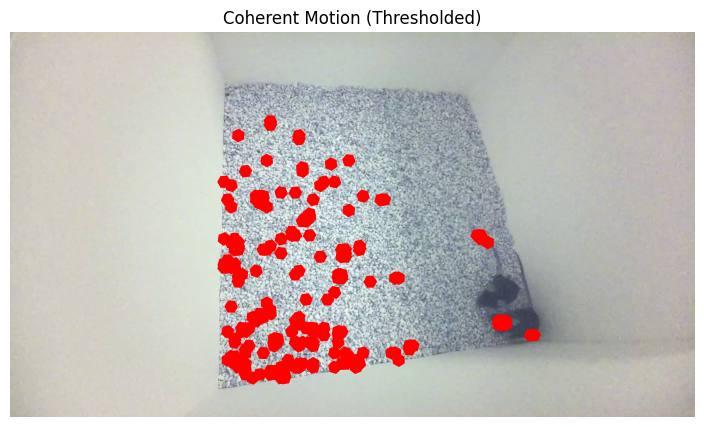

quantile:  2.0867985117689614e-09


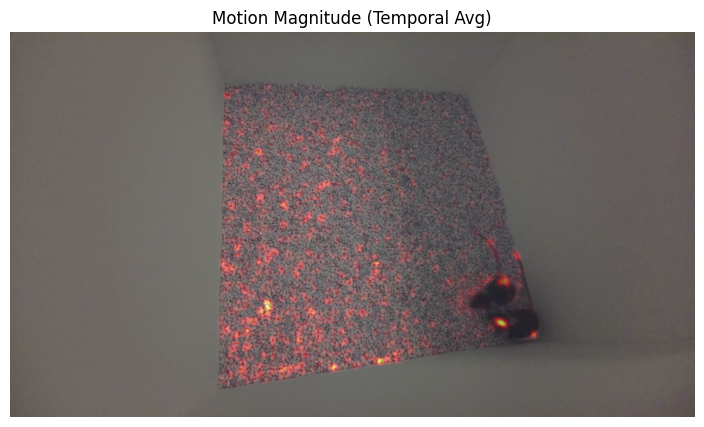

quantile:  2.0867985117689614e-09


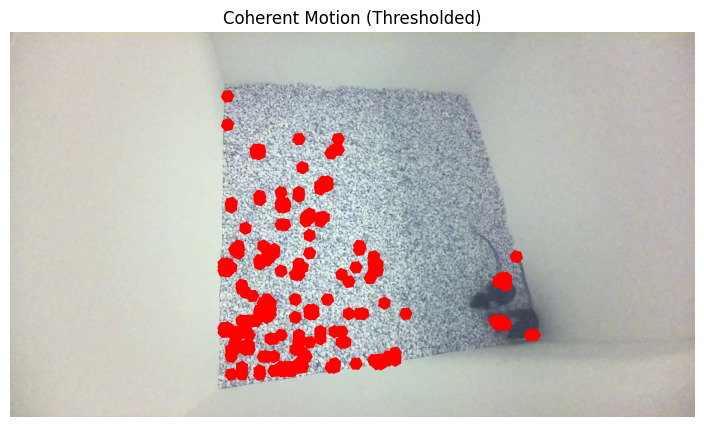

quantile:  2.0342456608091197e-09


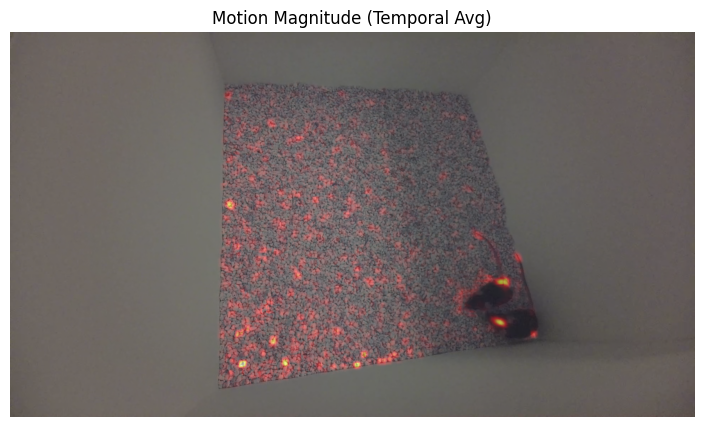

quantile:  2.0342456608091197e-09


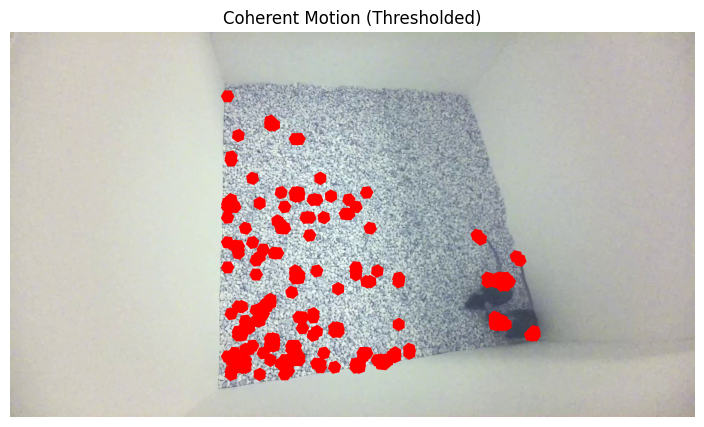

quantile:  2.016426137174676e-09


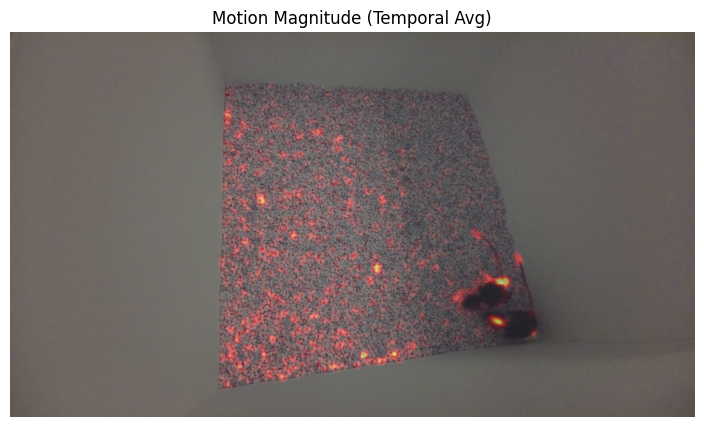

quantile:  2.016426137174676e-09


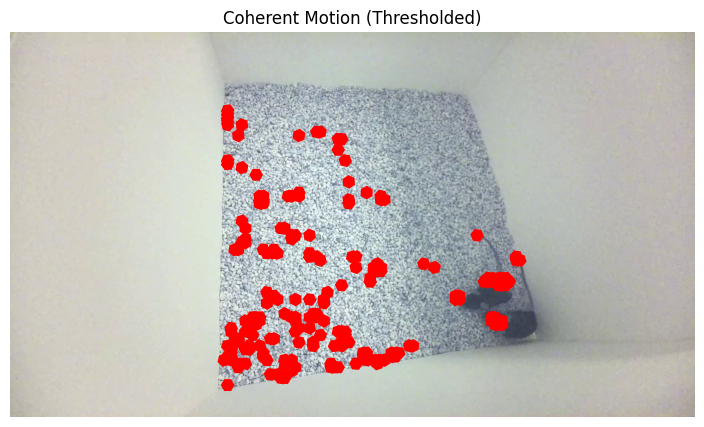

quantile:  2.0206665229949294e-09


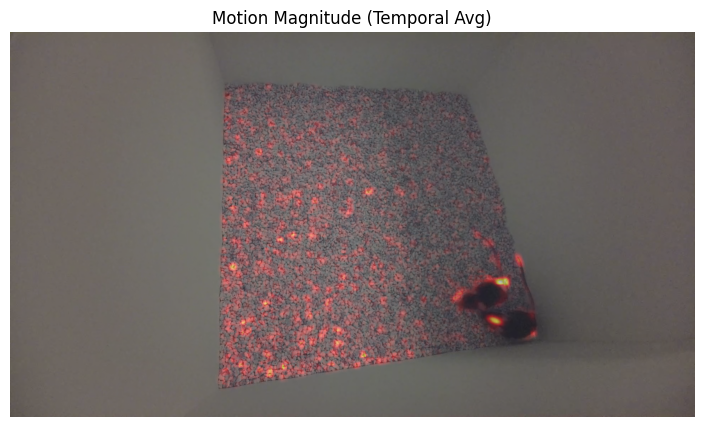

quantile:  2.0206665229949294e-09


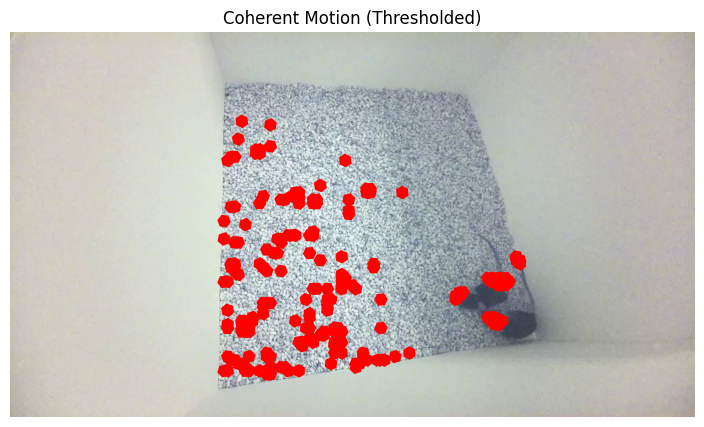

quantile:  2.0605384065675025e-09


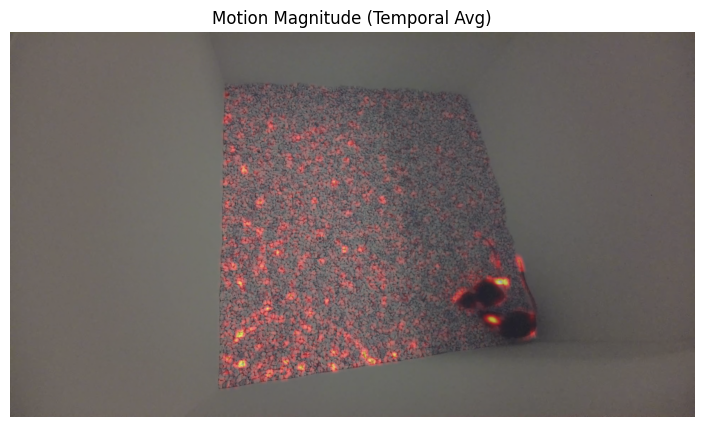

quantile:  2.0605384065675025e-09


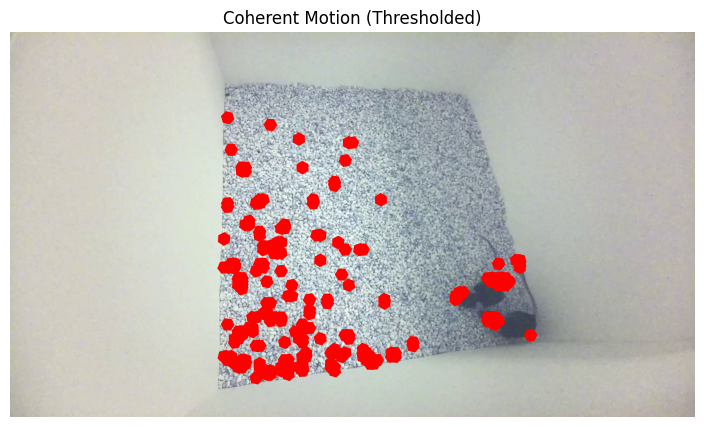

quantile:  1.974732377618693e-09


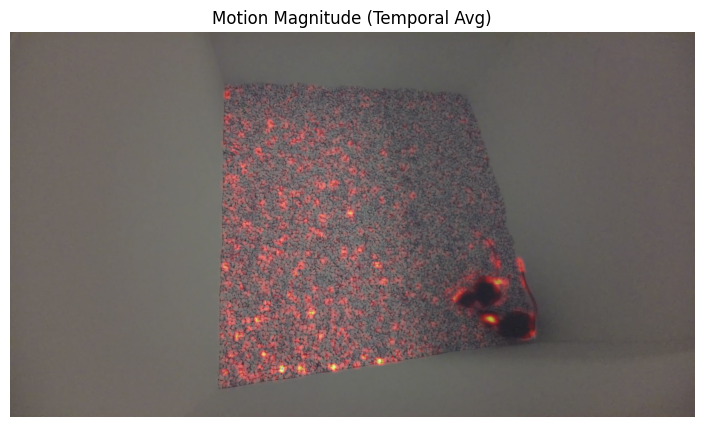

quantile:  1.974732377618693e-09


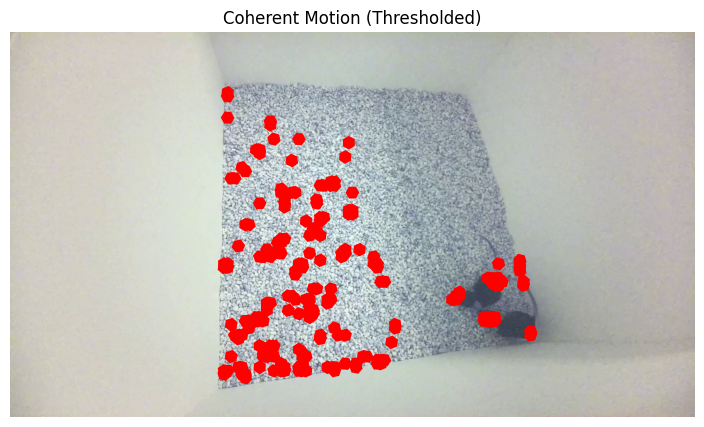

quantile:  2.081302685752462e-09


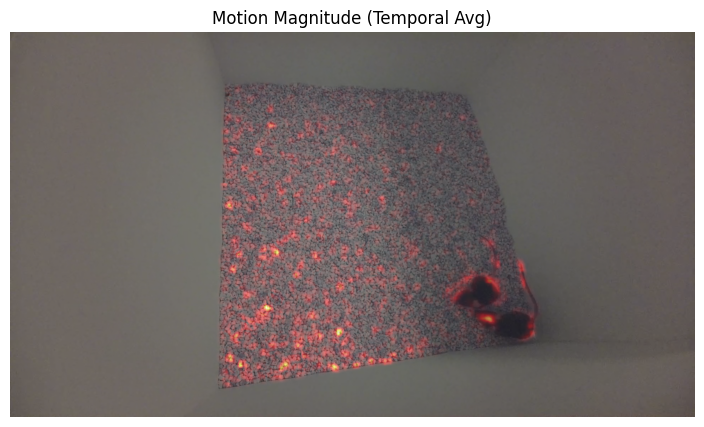

quantile:  2.081302685752462e-09


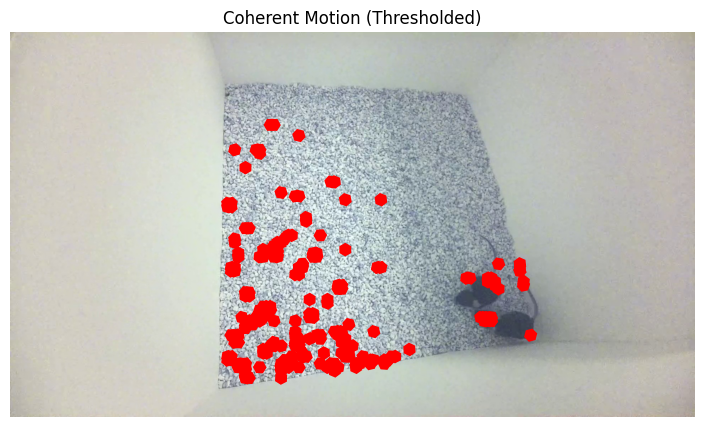

quantile:  1.9678632057207324e-09


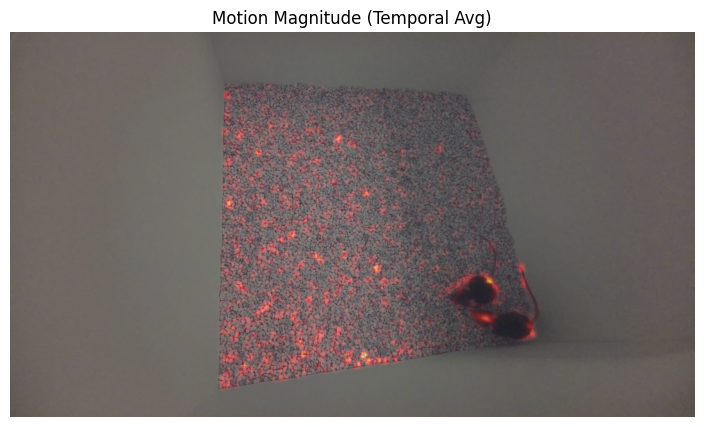

quantile:  1.9678632057207324e-09


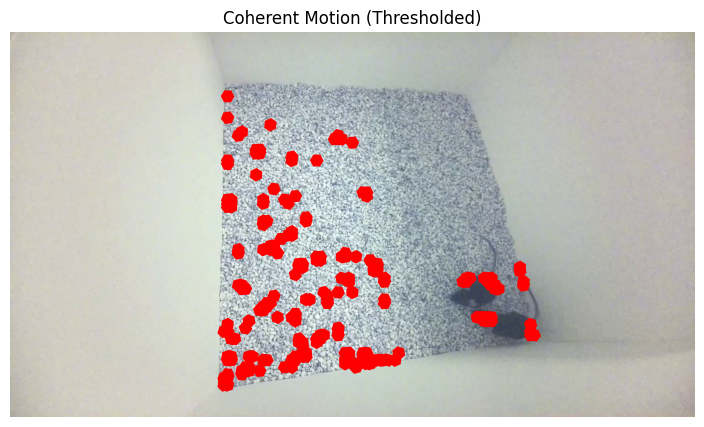

quantile:  1.971436569547791e-09


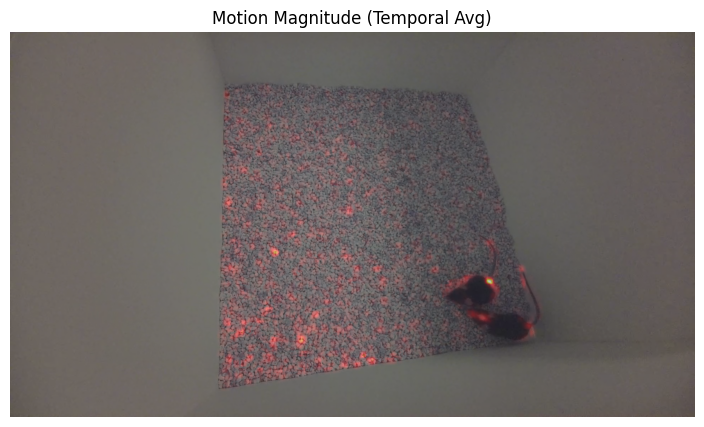

quantile:  1.971436569547791e-09


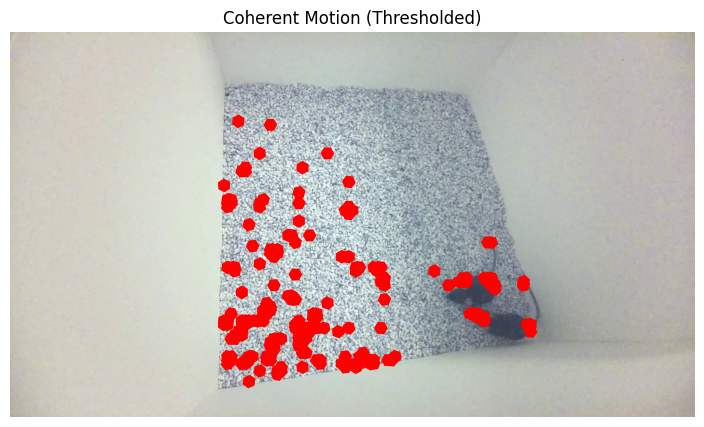

quantile:  2.0658315058597054e-09


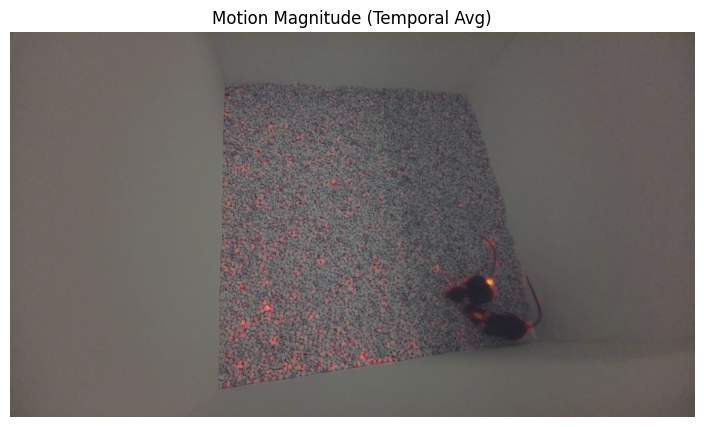

quantile:  2.0658315058597054e-09


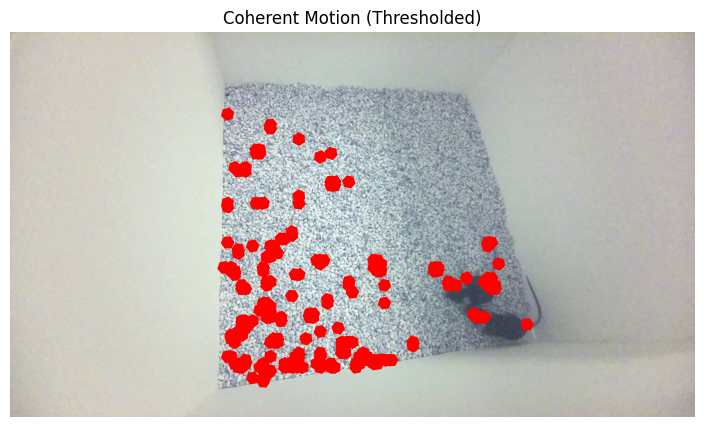

quantile:  2.071169458162103e-09


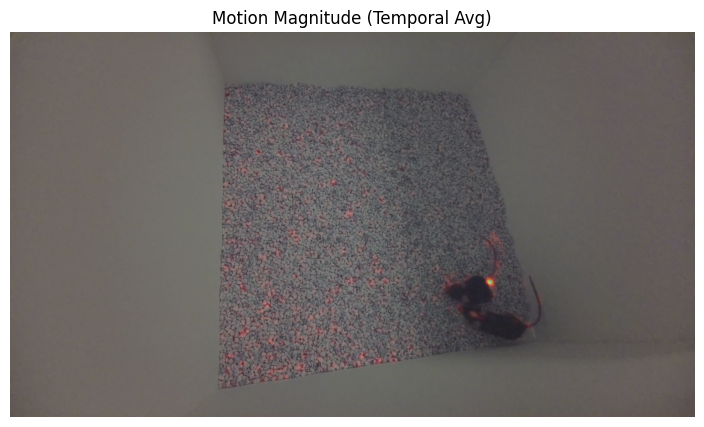

quantile:  2.071169458162103e-09


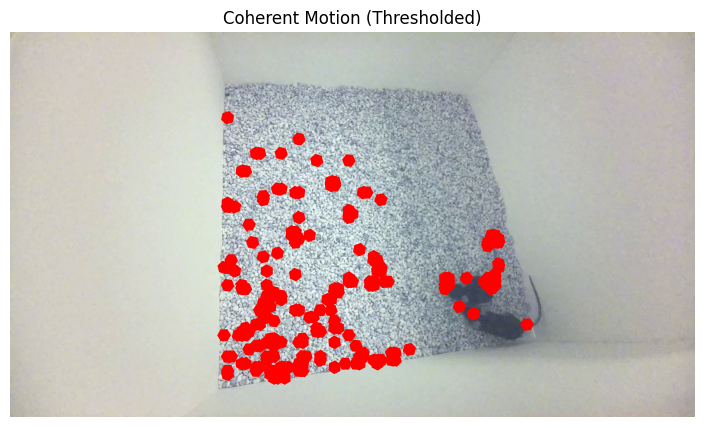

quantile:  2.157326983720509e-09


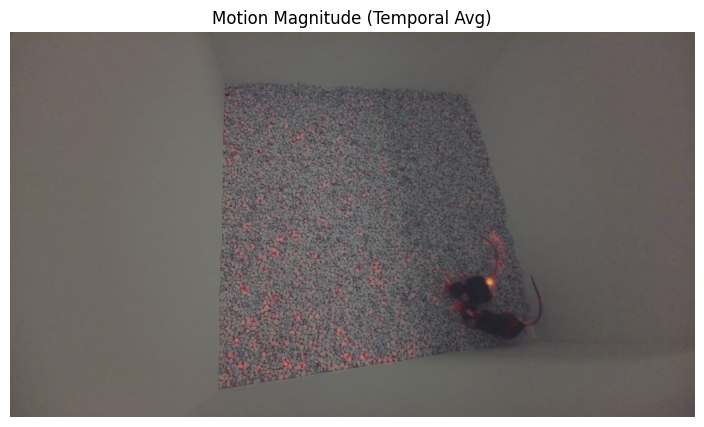

quantile:  2.157326983720509e-09


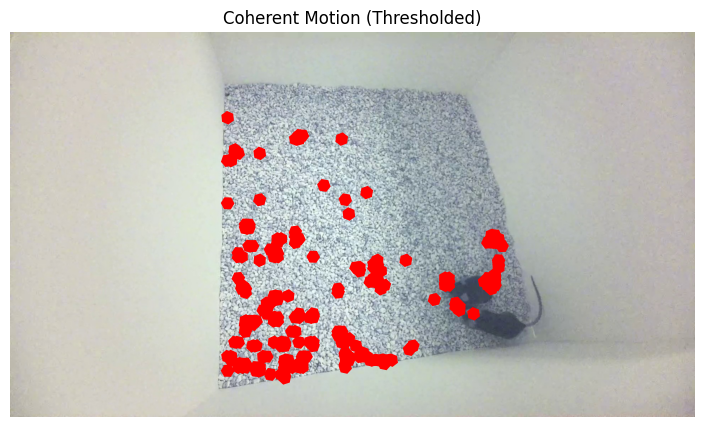

quantile:  2.3485142719437135e-09


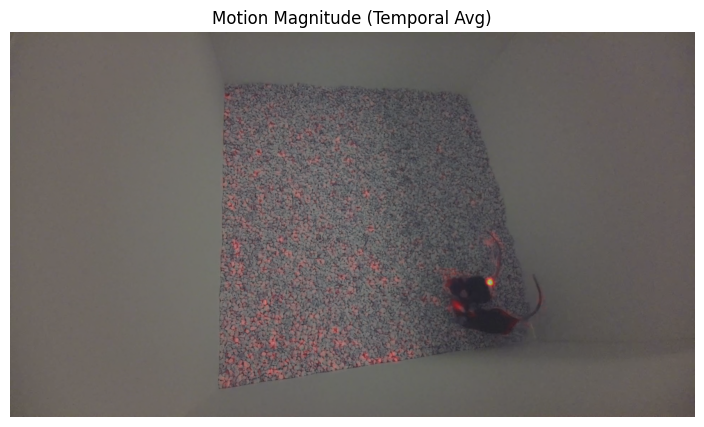

quantile:  2.3485142719437135e-09


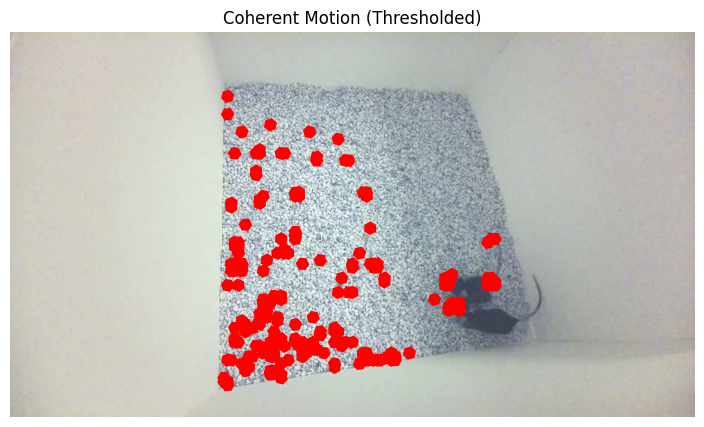

In [ ]:
run_pipeline(frames, K=5, mag_quantile_thresh=0.99, stride=10)

In [ ]:
render_flow_video(frames, compute_temporal_avg_flow(frames, K=5), out_path="flow.mp4", mag_quantile_thresh=0.99, stride=10)

KeyboardInterrupt: 

In [ ]:
from IPython.display import HTML
import base64

def display_video_inline(path, width=800):
    """
    Render an MP4 video inline in Jupyter.
    """
    with open(path, "rb") as f:
        video_bytes = f.read()

    video_b64 = base64.b64encode(video_bytes).decode("ascii")

    return HTML(f"""
    <video width="{width}" controls>
        <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """)

# usage
display_video_inline("flow.mp4")